# Introduction

Previously, we saw that a single R&F neuron can represent a quasi-static phase with respect to a reference wave. In this notebook, we'll run with that concept
to show that many oscillators can be used to construct an entire computing system based on analog values.

A challenge we introduced previously is "given a series of analog devices, how can we assemble them to do useful, reliable computation with low-precision
and variable components?" One approach to address this challenge is the field of hyperdimensional (HD) computation. HD computation focuses on using very large-scale
systems of specific values to carry out computations by harnessing the advantages of these large representations. You can see separate [introductory notebooks
for a more in-depth tutorial on HDC](https://github.com/wilkieolin/VSA-notebooks).

Essentially, HD systems generally define a "symbol" as a point in a high-dimensional space - in our case, a symbol is a vector of many phase angles. This can be implemented
via a bank of many oscillators which represent those phases. These symbols can then be manipulated via three "major" operations:

* Similarity: measuring how "close" two symbols are. Maps two symbols to a scalar.
* Bundling: takes many symbols, and produces a symbol which is maximally similar to the inputs. Maps multiple symbols to one symbol. Weights transform how similar the output will be to each input.
* Binding: takes one symbol and a set of symbols, and rotates the set of symbols by the input. Maps a set of symbols to a set of symbols. Weights transform how far each symbol is rotated.

These three operations are sufficient to create an extremely rich computing environment that can express any computible algorithm - although, with a probabilistic chance of getting the "correct" answer,
as these systems are inherently based on analog values with limited precisions.

## From neurons to operations

*Phasor networks, from the ground up — notebook 2 of 6.*

Why should a bank of oscillators be able to *do* all of this? The clue is already
in the neuron's own equation. In the last notebook we wrote a vector of R&F neurons
as

$$\frac{dz}{dt} = \underbrace{k\,z}_{\text{bind to self (rotation)}} + \underbrace{W\,I(t)}_{\text{bundle inputs (superposition)}}.$$

Each neuron already *rotates* its own state (the `k·z` term) and *superposes* the
inputs flowing into it (the `W·I(t)` term). Those two motions — **rotation** and
**superposition** — turn out to be the whole story. By arranging oscillators so
that one or the other dominates, we isolate each HD operation:

- **superposition** — *combine* oscillator states by adding them, `z_x + z_y`. The
  *magnitude* of the sum measures how much two phasors agree (**similarity**); the
  *angle* of the sum of many is their consensus (**bundling**).
- **rotation** — *phase-shift* one oscillator by another, `z_x · z_y`, i.e. add
  their angles. This is **binding**; running the rotation backwards is **unbinding**.

Throughout, we will compute each operation two ways — directly as phase algebra
(the *atemporal* view) and by letting oscillators evolve and interfere (the
*temporal* view) — and confirm they agree.

In [10]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using PhasorNetworks
using Plots
using Statistics: mean
using LinearAlgebra: diag
using Random: Xoshiro
using DifferentialEquations: Tsit5

  Activating project at `~/code/PhasorNetworks.jl`


## Superposition and rotation, on bare phasors

Before bringing in time, look at the two motions on static phasors. Take two
phases and view them as unit-circle points `z_x = exp(iπθ_x)` and
`z_y = exp(iπθ_y)`. **Adding** them and **multiplying** them already give all three
operations:

- `angle(z_x + z_y)` is the **bundle** — the consensus angle of the two,
- `|z_x + z_y|² / 2 − 1 = cos(π(θ_x − θ_y))` is the **similarity**,
- `angle(z_x · z_y) = π(θ_x + θ_y)` is the **bind** — the phases add.

The cell below confirms each of these numerically.

In [11]:
x = Float32[-0.5, -0.25, 0.0, 0.25, 0.5]
y = fill(0.1f0, length(x))
zx = angle_to_complex(x); zy = angle_to_complex(y)

bundle_cd = Float32.(complex_to_angle(zx .+ zy))
bind_cd   = Float32.(complex_to_angle(zx .* zy))
sim_cd    = abs2.(zx .+ zy) ./ 2 .- 1

println("bundle  angle(zx+zy) : ", bundle_cd)
println("bind    angle(zx*zy) : ", bind_cd, "   (= x + 0.1)")
println("similar |zx+zy|^2/2-1: ", Float32.(sim_cd))

bundle  angle(zx+zy) : Float32[-0.2, -0.074999996, 0.05, 0.175, 0.29999998]
bind    angle(zx*zy) : Float32[-0.4, -0.15, 0.1, 0.35, 0.59999996]   (= x + 0.1)
similar |zx+zy|^2/2-1: Float32[-0.30901706, 0.45399046, 0.95105636, 0.89100647, 0.30901694]


## Superposition → similarity

The first operation is **similarity**: a single number saying how close two symbols
are. For the FHRR system this is the mean cosine of the angle differences, so
identical symbols score `+1` and (in high dimensions) random symbols score about
`0`.

Where does that cosine come from physically? From **interference**. Two unit
phasors superpose to `z_x + z_y`, and the magnitude of that sum is

$$|z_x + z_y|^2 = 2 + 2\cos\big(\pi(\theta_x-\theta_y)\big) \;=\; 2 + 2\cos\Delta,
\qquad |z_x + z_y| = 2\,\big|\cos(\Delta/2)\big|.$$

So the interference magnitude *is* the agreement: in-phase phasors (`Δ = 0`) add to
length `2` (full constructive interference), anti-phase phasors (`Δ = ±π`) cancel to
`0`, and orthogonal phasors (`Δ = ±π/2`) give `√2`. Inverting the relation recovers
the cosine exactly — which is precisely what `interference_similarity` does in
`vsa.jl`:

$$\text{half\_angle} = \arccos\!\big(\tfrac{1}{2}|z_x+z_y|\big) = |\Delta/2|,
\qquad \text{sim} = \cos(2\cdot\text{half\_angle}) = \cos\Delta.$$

A pair of oscillators therefore *computes* similarity just by interfering: bright
(large `|sum|`) means similar, dark (cancellation) means opposite.

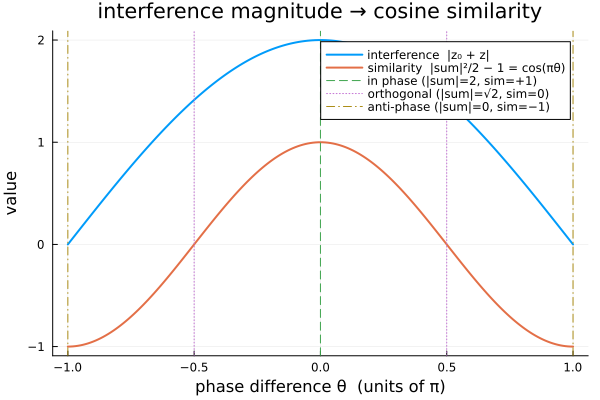

In [12]:
theta = Float32.(range(-1, 1, 201))           # phase difference, units of π
z0 = angle_to_complex([0.0f0])[1]
zd = angle_to_complex(theta)
mag = abs.(z0 .+ zd)                           # interference magnitude |z0 + z|
sim = mag .^ 2 ./ 2 .- 1                       # = cos(πθ)

plot(theta, mag, label="interference  |z₀ + z|", lw=2,
     xlabel="phase difference θ  (units of π)", ylabel="value",
     title="interference magnitude → cosine similarity")
plot!(theta, sim, label="similarity  |sum|²/2 − 1 = cos(πθ)", lw=2)
vline!([0.0], label="in phase (|sum|=2, sim=+1)", ls=:dash)
vline!([-0.5, 0.5], label="orthogonal (|sum|=√2, sim=0)", ls=:dot)
vline!([-1.0, 1.0], label="anti-phase (|sum|=0, sim=−1)", ls=:dashdot)

Scaling this up to whole symbols, `similarity_outer` compares every phase in one
set against every phase in another. Sweeping two phases over `[-1, 1]` traces the
full cosine ridge: a bright in-phase diagonal falling away to the anti-phase
corners.

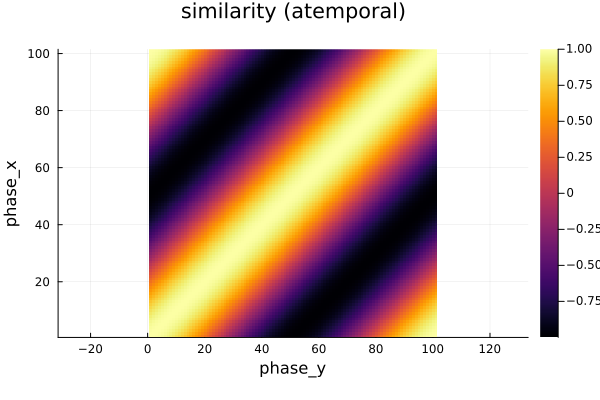

In [13]:
n_x = 101; n_y = 101; n_vsa = 1
phase_x = reshape(range(-1.0, 1.0, n_x), (1, n_x, n_vsa)) |> collect
phase_y = reshape(range(-1.0, 1.0, n_y), (1, n_y, n_vsa)) |> collect

sims = similarity_outer(phase_x, phase_y, dims=2)[:, :, 1]
heatmap(sims, aspect_ratio=:equal, title="similarity (atemporal)",
        xlabel="phase_y", ylabel="phase_x")

Run on oscillators, the very same matrix emerges from interference as the two
banks settle. Each cycle sharpens the estimate; correlating the oscillator matrix
against the atemporal one shows it climbing to ≈1 — the temporal computation
converges to the static answer.

final correlation with atemporal: 0.999999959724644


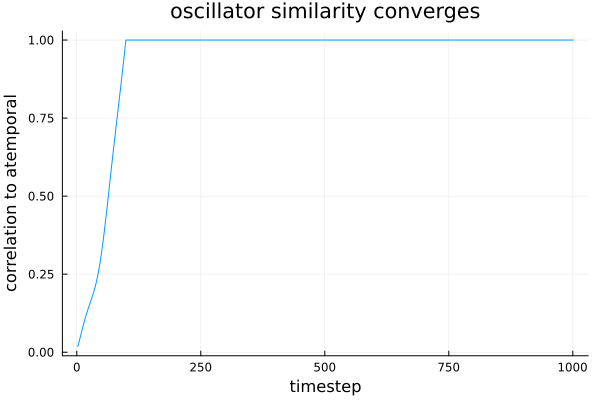

In [14]:
solver_args = Dict(:adaptive => false, :dt => 0.01, :abstol => 1e-6, :reltol => 1e-6)
spk_sim = SpikingArgs(t_window = 0.01, threshold = 0.001, solver = Tsit5(), solver_args = solver_args)
repeats = 10; tspan = (0.0, repeats * 1.0)

st_x = phase_to_train(phase_x, spk_args=spk_sim, repeats=repeats)
st_y = phase_to_train(phase_y, spk_args=spk_sim, repeats=repeats)
sims_t = similarity_outer(st_x, st_y, tspan=tspan, spk_args=spk_sim) |> stack

acc_t = [cor_realvals(vec(sims), vec(sims_t[:, :, 1, t])) for t in 1:size(sims_t, 4)]
println("final correlation with atemporal: ", acc_t[end])
plot(acc_t, xlabel="timestep", ylabel="correlation to atemporal", label="",
     title="oscillator similarity converges")

## Superposition → bundling

Similarity reads out a superposition; **bundling** *keeps* it. If we sum a set of
phasors and read the **angle** of the result, we get a single symbol that points
"between" its inputs — maximally similar to all of them at once. In the VSA picture
this is the *center of the constellation*: bundling `dog`, `cat`, and `tiger` gives
an `animals` symbol close to each.

Physically it is just vector addition of the sub-phasors. The cell below bundles a
handful of phases: each input is an arrow on the unit circle, and their resultant
(black) points along the bundle. The resultant's *length* also tells us the
agreement — tightly-clustered inputs add up to a long, confident resultant; spread
-out inputs partially cancel into a short one.

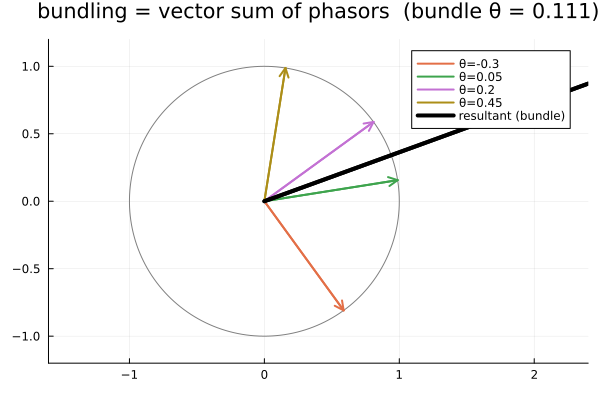

In [15]:
ph = Float32[-0.30, 0.05, 0.20, 0.45]
zs = angle_to_complex(ph)
res = sum(zs)
bundle = Float32(complex_to_angle([res])[1])

circ = exp.(im .* range(0, 2pi, 200))
plt = plot(real.(circ), imag.(circ), color=:gray, label="", aspect_ratio=:equal,
           xlims=(-1.6, 2.4), ylims=(-1.2, 1.2),
           title="bundling = vector sum of phasors  (bundle θ = $(round(bundle, digits=3)))")
for (i, z) in enumerate(zs)
    plot!(plt, [0, real(z)], [0, imag(z)], arrow=true, lw=2, label="θ=$(ph[i])")
end
plot!(plt, [0, real(res)], [0, imag(res)], arrow=true, lw=4, color=:black, label="resultant (bundle)")

The oscillator bank does exactly this addition in its membrane potentials: the
sub-potentials interfere and `solution_to_phase` reads the angle of the sum. Over a
grid of `(x, y)` pairs, the oscillator bundle matches the atemporal `v_bundle` to
within a tiny circular error.

max arc error: 0.001941028


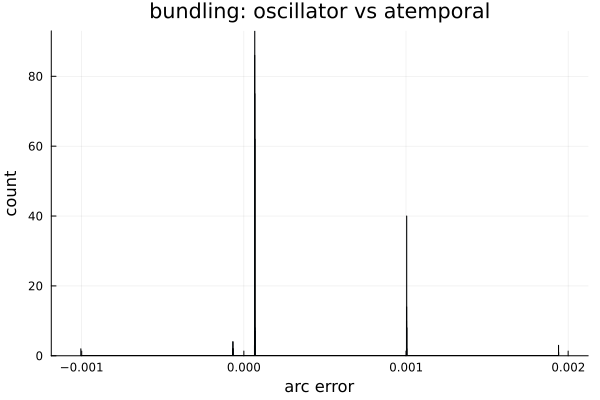

In [16]:
phases = collect([[a, b] for a in range(-1.0, 1.0, 21), b in range(-1.0, 1.0, 21)]) |> stack
phases = reshape(phases, (1, 2, :))
b = v_bundle(phases, dims=2)

spk_bun = SpikingArgs(solver_args = Dict(:adaptive => false, :dt => 0.01), threshold = 0.001)
tspan_b = (0.0, 6.0); tbase_b = collect(0.0:0.01:tspan_b[2])
stb = phase_to_train(phases, spk_args=spk_bun, repeats=6)
solb = v_bundle(stb, dims=2, spk_args=spk_bun, tspan=tspan_b, return_solution=true)
b_osc = solution_to_phase(solb, tbase_b, spk_args=spk_bun, offset=0.0)

err = arc_error.(vec(b_osc[1, 1, :, end]) .- vec(b))
println("max arc error: ", maximum(err))
histogram(err, xlabel="arc error", ylabel="count", label="",
          title="bundling: oscillator vs atemporal")

## Rotation → binding

The last operation, **binding** (written `×`), also fuses inputs into one symbol —
but the result is *dissimilar* to its inputs. That sounds destructive, yet binding
is the key to structure: it is *similarity-preserving*
(`sim(A, B) ≈ sim(A×C, B×C)`), so it rigidly *shifts the whole constellation* to a
new region without distorting it. That is what lets us tag `Alice × Bob` as an edge
distinct from every node yet still comparable to other edges — the basis for the
graph in the next notebook.

In the complex plane binding is **multiplication**: `z_x · z_y = exp(iπ(θ_x+θ_y))`
— the angles add, so `z_y` *rotates* `z_x` by its phase.

On oscillators there is a subtlety. Each carries the moving carrier
`z_x(t) = exp(i(ωt + πθ_x))`, and the product of two oscillators

$$z_x(t)\,z_y(t) = \exp\!\big(i(2\omega t + \pi(\theta_x+\theta_y))\big)$$

spins at **twice** the carrier frequency — which would break phase-locked
communication with the rest of the network. The fix, which `v_bind` applies, is a
**derotation**: multiply by the conjugate of a reference oscillator
`exp(−iωt)` to bring the result back to the carrier `ω` while keeping the summed
phase:

$$z_x(t)\,z_y(t)\,\overline{z_\text{ref}(t)} = \exp\!\big(i(\omega t + \pi(\theta_x+\theta_y))\big).$$

(In `vsa.jl`, that conjugate-reference factor is exactly the `conj(u_ref)` term in
`v_bind`.) The animation below shows it in motion: `z_x` and `z_y` rotate at the
carrier, and the derotated product (the bound symbol) also rotates at the carrier —
permanently *ahead of* `z_x` by `z_y`'s phase.

[ Info: Saved animation to /home/wilkie/code/PhasorNetworks.jl/demos/tmp.gif


Plots.AnimatedGif("/home/wilkie/code/PhasorNetworks.jl/demos/tmp.gif")
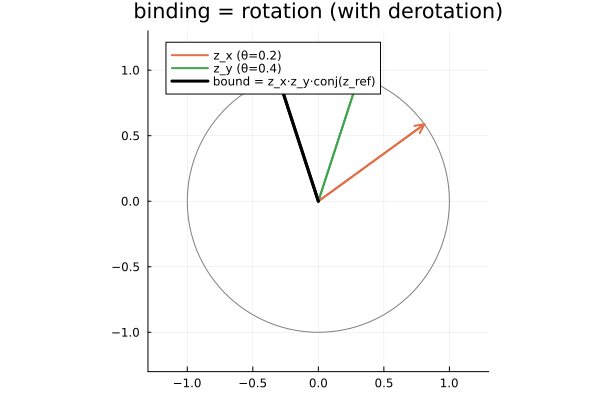

In [17]:
omega = Float32(period_to_angfreq(1.0))
thx = 0.2f0; thy = 0.4f0                      # bind: result should lead z_x by πθy

anim = @animate for t in range(0, 1, 40)
    zx = exp(im * (omega * t + pi * thx))
    zy = exp(im * (omega * t + pi * thy))
    zref = exp(im * omega * t)
    bound = zx * zy * conj(zref)              # derotated product: phase θx+θy at carrier ω

    circ = exp.(im .* range(0, 2pi, 120))
    plot(real.(circ), imag.(circ), color=:gray, label="", aspect_ratio=:equal,
         xlims=(-1.3, 1.3), ylims=(-1.3, 1.3), title="binding = rotation (with derotation)")
    plot!([0, real(zx)], [0, imag(zx)], arrow=true, lw=2, label="z_x (θ=$thx)")
    plot!([0, real(zy)], [0, imag(zy)], arrow=true, lw=2, label="z_y (θ=$thy)")
    plot!([0, real(bound)], [0, imag(bound)], arrow=true, lw=3, color=:black, label="bound = z_x·z_y·conj(z_ref)")
end
gif(anim, fps=18)

Scaled to whole symbols, atemporal and oscillator binding agree, and `v_unbind`
rotates back to recover an operand.

unbind recovers x: similarity = 1.0


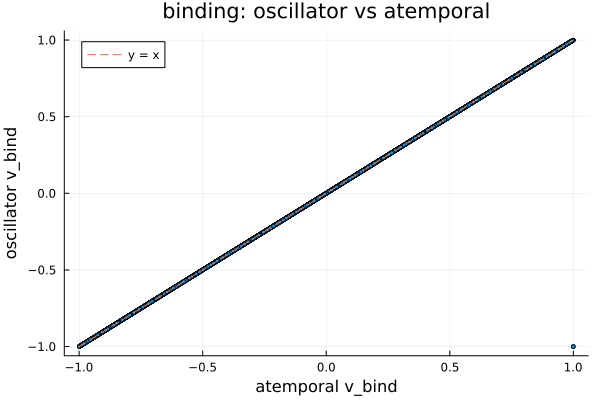

In [18]:
rng = Xoshiro(42)
xb = random_symbols(rng, (1024, 10)); yb = random_symbols(rng, (1024, 10))
zb = v_bind(xb, yb)
xb_rec = v_unbind(zb, yb)
println("unbind recovers x: similarity = ", mean(diag(similarity_outer(xb, xb_rec, dims=1))))

spk_bind = SpikingArgs()
xs = phase_to_train(xb, spk_args=spk_bind, repeats=10)
ys = phase_to_train(yb, spk_args=spk_bind, repeats=10)
xc = SpikingCall(xs, spk_bind, (0.0, 10.0)); yc = SpikingCall(ys, spk_bind, (0.0, 10.0))
zc = v_bind(xc, yc)
zc_p = train_to_phase(zc)

scatter(vec(zb), vec(zc_p[:, :, end]), xlabel="atemporal v_bind", ylabel="oscillator v_bind",
        label="", markersize=2, title="binding: oscillator vs atemporal")
plot!(-1:1, -1:1, label="y = x", linestyle=:dash)

## Summary

| operation | primitive | on phasors | packaged |
|-----------|-----------|------------|----------|
| similarity | superposition | `\|z_x + z_y\|` | `similarity_outer` |
| bundling | superposition | `angle(Σ z)` | `v_bundle` |
| binding | rotation | `angle(z_x · z_y)` | `v_bind` / `v_unbind` |

Connecting oscillators by superposition and rotation gives the full FHRR algebra,
and each operation runs identically as static phase algebra or as interfering
oscillators. The remaining notebooks build on these three operations: **resonator
networks** (notebook 3) factor bound products, **graph queries** (4) store and
traverse structure, **neural networks** (5) learn with them, and the **temporal
SSM** (6) makes the per-cycle phase itself the carrier of information.